In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv('ecommerce_sales_1000_records.csv')
df.head(25)

,Order_ID,Product,Category,Quantity,Price,City,Date
0,ORD1001,Backpack,Accessories,1,1629.00,Hyderabad,2026-03-04
1,ORD1002,Keyboard,Electronics,2,1570.94,Surat,2026-01-23
2,ORD1003,Book,Books,4,407.86,Mumbai,2026-02-25
3,ORD1004,Keyboard,Electronics,5,1530.61,Surat,2026-02-20
4,ORD1005,Tablet,Electronics,5,27549.31,Jaipur,2026-05-31
5,ORD1006,T-Shirt,Fashion,1,840.36,Delhi,2026-06-28
6,ORD1007,Watch,Accessories,3,4776.92,Bangalore,2026-03-28
7,ORD1008,Smartphone,Electronics,1,17567.74,Pune,2026-03-30
8,ORD1009,Book,Books,3,477.64,Jaipur,2026-05-18
9,ORD1010,Smartphone,Electronics,4,16483.68,Hyderabad,2026-06-10


In [23]:
df['Date'] = pd.to_datetime(df['Date'])

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Order_ID  1000 non-null   str           
 1   Product   1000 non-null   str           
 2   Category  1000 non-null   str           
 3   Quantity  1000 non-null   int64         
 4   Price     1000 non-null   float64       
 5   City      1000 non-null   str           
 6   Date      1000 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(1), str(4)
memory usage: 54.8 KB


In [25]:
df['Revenue'] = df['Price'] * df['Quantity']

In [26]:
df.describe()

,Quantity,Price,Date,Revenue
count,1000.000000,1000.000000,1000,1000.000000
mean,3.035000,8940.486210,2026-03-31 13:56:38.400000,27620.651090
min,1.000000,407.430000,2026-01-01 00:00:00,410.560000
25%,2.000000,1738.235000,2026-02-15 00:00:00,3800.072500
50%,3.000000,2962.040000,2026-03-31 00:00:00,8488.360000
75%,4.000000,6263.752500,2026-05-14 00:00:00,20335.462500
max,5.000000,60347.510000,2026-06-29 00:00:00,299643.450000
std,1.402049,14229.456287,NaN,50826.518023


In [27]:
total_revenue = df['Revenue'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $27,620,651.09


In [28]:
product_sales = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
print(product_sales.sort_values(ascending=False))

Product
T-Shirt         259
Backpack        241
Watch           241
Air Fryer       239
Mixer           226
Keyboard        218
Tablet          215
Jeans           214
Laptop          207
Shoes           206
Book            199
Smartphone      199
Coffee Maker    193
Headphones      178
Name: Quantity, dtype: int64


In [29]:
category_sales = df.groupby('Category')['Quantity'].sum().sort_values(ascending=False)
print(category_sales.sort_values(ascending=False))

Category
Electronics        1017
Fashion             679
Home Appliances     658
Accessories         482
Books               199
Name: Quantity, dtype: int64


In [30]:
df['Month'] = df['Date'].dt.month_name()
monthly_revenue = df.groupby('Month')['Revenue'].sum().sort_values(ascending=False)
print(monthly_revenue)

Month
January     5205216.14
May         4860089.35
March       4668486.25
April       4655427.19
February    4418598.64
June        3812833.52
Name: Revenue, dtype: float64


In [31]:
city_sales = df.groupby('City')['Revenue'].sum().sort_values(ascending=False)
print(city_sales)

City
Pune         3262077.43
Mumbai       3213056.46
Jaipur       3161091.50
Bangalore    3148292.69
Kolkata      2971339.46
Surat        2798244.03
Delhi        2660336.42
Chennai      2359385.36
Ahmedabad    2127277.96
Hyderabad    1919549.78
Name: Revenue, dtype: float64


In [32]:
average_order = df['Revenue'].mean()
print("Average Order Value : ${:,.2f}".format(average_order))

Average Order Value : $27,620.65


In [33]:
top_products = df.sort_values(by='Price', ascending=False)
print(top_products[['Product','Price']].head(10))

    Product     Price
504  Laptop  60347.51
108  Laptop  60323.30
465  Laptop  60008.45
630  Laptop  59970.26
685  Laptop  59935.48
154  Laptop  59928.69
752  Laptop  59923.15
428  Laptop  59899.23
546  Laptop  59897.07
533  Laptop  59808.76


In [34]:
city_orders = df['City'].value_counts().sort_values(ascending=False)
print(city_orders)

City
Mumbai       126
Surat        105
Jaipur       105
Pune         102
Ahmedabad     99
Chennai       98
Hyderabad     96
Delhi         94
Bangalore     88
Kolkata       87
Name: count, dtype: int64


In [35]:
category_revenue = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
print(category_revenue)

Category
Electronics        21606517.72
Home Appliances     3141481.72
Accessories         1630446.50
Fashion             1152368.38
Books                 89836.77
Name: Revenue, dtype: float64


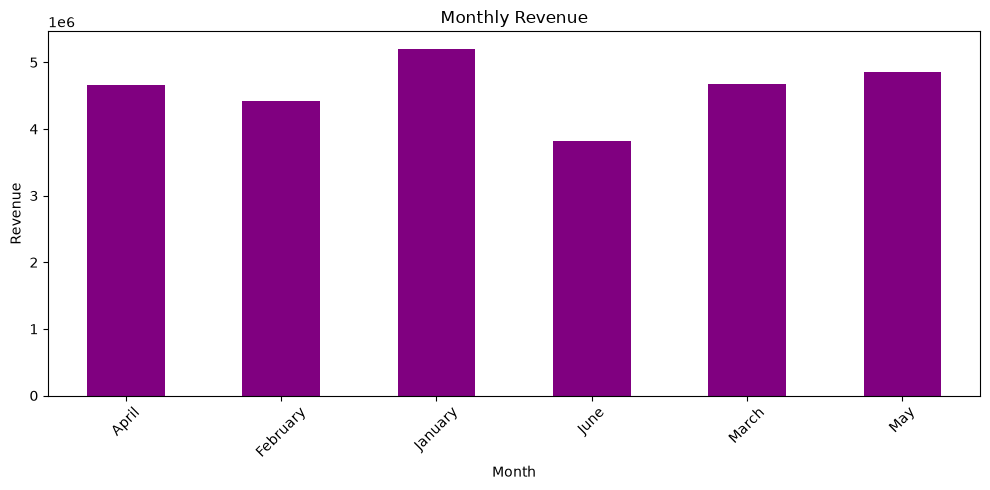

In [36]:
import matplotlib.pyplot as plt
df['Month'] = df['Date'].dt.month_name()
monthly_revenue = df.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(10,5))
monthly_revenue.plot(kind='bar', color = 'Purple')

plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

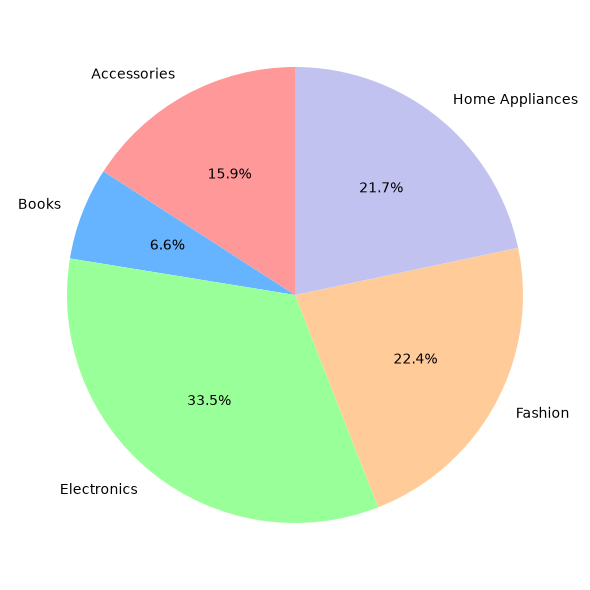

In [37]:
category_sales = df.groupby('Category')['Quantity'].sum()

plt.figure(figsize=(8,6))
category_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0','#ffb3e6'])
plt.title = ('Category Distribution')
plt.ylabel('')

plt.tight_layout()
plt.show()

TypeError: 'str' object is not callable

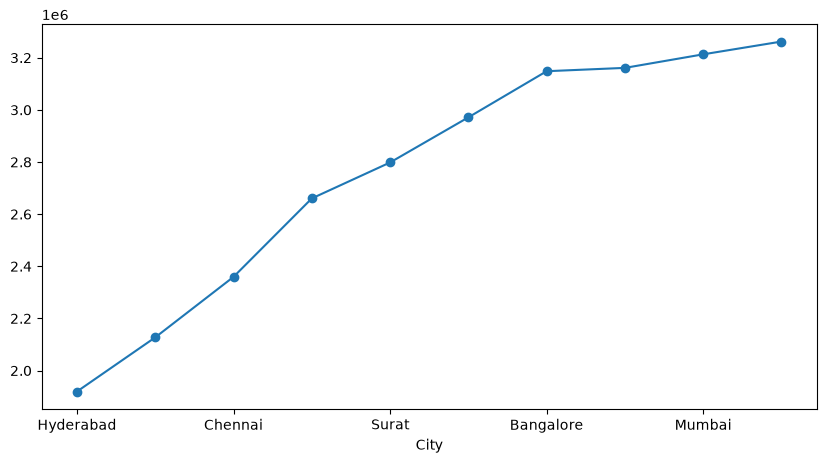

In [38]:
city_sales = df.groupby('City')['Revenue'].sum()

plt.figure(figsize=(10,5))
city_sales.sort_values().plot(kind='line',marker = 'o')
plt.title('City-wise Revenue')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()  

In [39]:
most_ordered = df.groupby('Product')['Quantity'].sum().idxmax()
print(f'Most Ordered Product: {most_ordered}')

Most Ordered Product: T-Shirt


In [40]:
report_sst = df.groupby('Category').agg({
    'Quantity' : 'sum',
    'Revenue' : 'sum'
})

print(report_sst)

                 Quantity      Revenue
Category                              
Accessories           482   1630446.50
Books                 199     89836.77
Electronics          1017  21606517.72
Fashion               679   1152368.38
Home Appliances       658   3141481.72
